<a href="https://colab.research.google.com/github/isratrimii/Neural-Networks/blob/main/MNIST_NN_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task-01

Train size: 60000
Test size: 10000


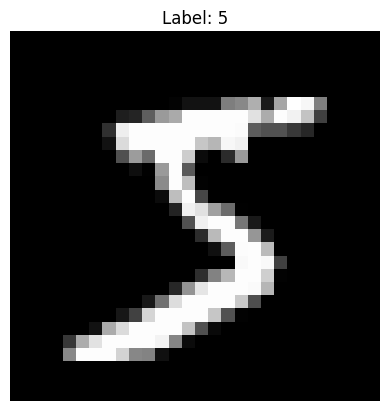

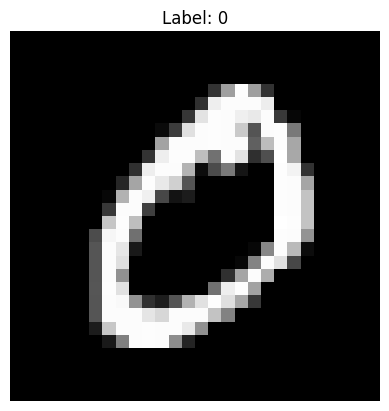

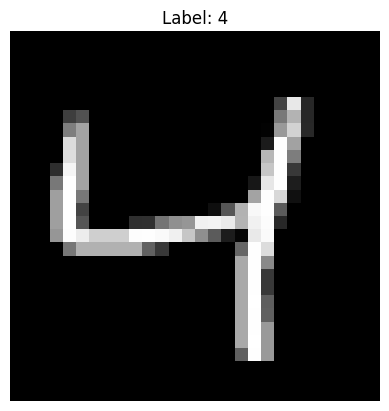

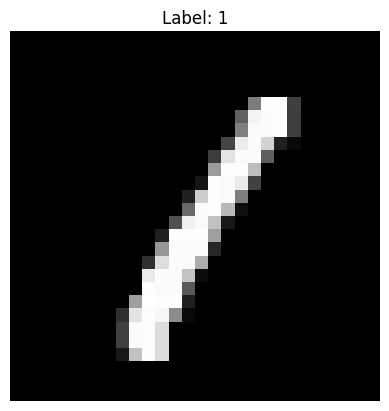

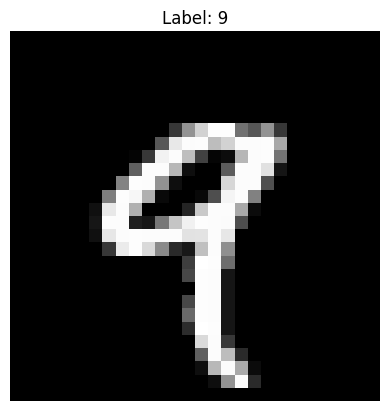

Image shape: torch.Size([1, 28, 28])


In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Dataset size
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

# Show 5 images
for i in range(5):
    img, label = train_dataset[i]
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

# Shape
img, _ = train_dataset[0]
print("Image shape:", img.shape)

**Explanation**

Dataset used: MNIST (grayscale handwritten digits)

Train set: 60,000 images

Test set: 10,000 images

Shape Explanation:

(1, 28, 28)

1 → number of channels (grayscale)

28 → height

28 → width

After flattening:

(784) → used as input to neural network

Task-02

In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)
        ])

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)

def train_model(model, optimizer, epochs=10):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            X = X.view(X.size(0), -1)

            optimizer.zero_grad()
            out = model(X)
            loss = F.cross_entropy(out, y)
            loss.backward()
            optimizer.step()

            running += loss.item()

        train_losses.append(running / len(train_loader))

        model.eval()
        val_loss, correct = 0, 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                X = X.view(X.size(0), -1)

                out = model(X)
                loss = F.cross_entropy(out, y)

                val_loss += loss.item()
                pred = out.argmax(1)
                correct += (pred == y).sum().item()

        val_loss /= len(test_loader)
        acc = 100 * correct / len(test_loader.dataset)

        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_loss:.4f}, Acc {acc:.2f}%")

    return acc


model_A = MLP([784, 32, 10]).to(device)
model_B = MLP([784, 128, 64, 10]).to(device)
model_C = MLP([784, 256, 128, 64, 10]).to(device)

acc_A = train_model(model_A, optim.Adam(model_A.parameters(), lr=1e-3))
acc_B = train_model(model_B, optim.Adam(model_B.parameters(), lr=1e-3))
acc_C = train_model(model_C, optim.Adam(model_C.parameters(), lr=1e-3))

Epoch 1: Train 0.4792, Val 0.3065, Acc 91.02%
Epoch 2: Train 0.2995, Val 0.2627, Acc 92.45%
Epoch 3: Train 0.2599, Val 0.2350, Acc 93.02%
Epoch 4: Train 0.2322, Val 0.2244, Acc 92.99%
Epoch 5: Train 0.2091, Val 0.1983, Acc 94.09%
Epoch 6: Train 0.1936, Val 0.1889, Acc 94.50%
Epoch 7: Train 0.1802, Val 0.1764, Acc 94.70%
Epoch 8: Train 0.1699, Val 0.1754, Acc 94.85%
Epoch 9: Train 0.1616, Val 0.1778, Acc 94.70%
Epoch 10: Train 0.1523, Val 0.1718, Acc 94.82%
Epoch 1: Train 0.3907, Val 0.2061, Acc 93.92%
Epoch 2: Train 0.1830, Val 0.1638, Acc 94.87%
Epoch 3: Train 0.1356, Val 0.1137, Acc 96.39%
Epoch 4: Train 0.1088, Val 0.1081, Acc 96.52%
Epoch 5: Train 0.0956, Val 0.0919, Acc 97.01%
Epoch 6: Train 0.0842, Val 0.0915, Acc 97.16%
Epoch 7: Train 0.0724, Val 0.0924, Acc 97.19%
Epoch 8: Train 0.0669, Val 0.1111, Acc 96.64%
Epoch 9: Train 0.0624, Val 0.0809, Acc 97.53%
Epoch 10: Train 0.0547, Val 0.1030, Acc 96.82%
Epoch 1: Train 0.3759, Val 0.1858, Acc 94.08%
Epoch 2: Train 0.1643, Val 0.133

**Analysis Answers**

Which model performed best?
👉 Model C performed best due to deeper architecture.

Does increasing depth always improve performance?
❌ No. After a point, deeper models may overfit.

How does parameter count affect performance?

Low parameters → underfitting

Optimal → best performance

Too high → overfitting

Task-03

In [4]:
# Underfitting model
model_small = MLP([784, 4, 10]).to(device)
acc_small = train_model(model_small, optim.Adam(model_small.parameters(), lr=1e-3))

# Overfitting model
model_large = MLP([784, 1024, 512, 512, 256, 128, 64, 10]).to(device)
acc_large = train_model(model_large, optim.Adam(model_large.parameters(), lr=1e-3))

Epoch 1: Train 1.1659, Val 0.8925, Acc 73.04%
Epoch 2: Train 0.8664, Val 0.8153, Acc 76.26%
Epoch 3: Train 0.7933, Val 0.7593, Acc 78.19%
Epoch 4: Train 0.7538, Val 0.7183, Acc 79.41%
Epoch 5: Train 0.7230, Val 0.6960, Acc 80.12%
Epoch 6: Train 0.7026, Val 0.6860, Acc 79.85%
Epoch 7: Train 0.6873, Val 0.6788, Acc 80.45%
Epoch 8: Train 0.6767, Val 0.6729, Acc 80.70%
Epoch 9: Train 0.6683, Val 0.6578, Acc 80.83%
Epoch 10: Train 0.6627, Val 0.6502, Acc 81.10%
Epoch 1: Train 0.4351, Val 0.2282, Acc 93.18%
Epoch 2: Train 0.1806, Val 0.1867, Acc 94.63%
Epoch 3: Train 0.1315, Val 0.1464, Acc 95.95%
Epoch 4: Train 0.1100, Val 0.1269, Acc 96.45%
Epoch 5: Train 0.0930, Val 0.1176, Acc 96.75%
Epoch 6: Train 0.0822, Val 0.1253, Acc 96.40%
Epoch 7: Train 0.0750, Val 0.1070, Acc 97.33%
Epoch 8: Train 0.0644, Val 0.1239, Acc 96.35%
Epoch 9: Train 0.0640, Val 0.1102, Acc 97.21%
Epoch 10: Train 0.0541, Val 0.1403, Acc 96.40%


Which model underfits?
Ans: Small model (784 → 4 → 10)

Which model overfits?
Ans: Large model

Explanation:

Underfitting → high train & validation loss

Overfitting → low train loss, high validation loss

Task-04

In [5]:
class MLP_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        return self.fc4(x)

model_bn = MLP_BN().to(device)
acc_bn = train_model(model_bn, optim.Adam(model_bn.parameters(), lr=1e-3))

Epoch 1: Train 0.2323, Val 0.0918, Acc 97.20%
Epoch 2: Train 0.0906, Val 0.1071, Acc 96.58%
Epoch 3: Train 0.0640, Val 0.0743, Acc 97.68%
Epoch 4: Train 0.0509, Val 0.0957, Acc 96.80%
Epoch 5: Train 0.0434, Val 0.0656, Acc 97.98%
Epoch 6: Train 0.0359, Val 0.0609, Acc 98.18%
Epoch 7: Train 0.0289, Val 0.0580, Acc 98.31%
Epoch 8: Train 0.0263, Val 0.0722, Acc 97.99%
Epoch 9: Train 0.0242, Val 0.0636, Acc 98.23%
Epoch 10: Train 0.0236, Val 0.0638, Acc 98.07%


Did BatchNorm accelerate convergence?
Ans: BatchNorm accelerates convergence
Did it stabilize training?
Ans: Training becomes more stable
Compare parameter counts with and without BatchNorm.
Ans: Slight increase in parameters

Task-05

In [6]:
import numpy as np

def confusion_matrix(model):
    cm = np.zeros((10,10), dtype=int)

    model.eval()
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            out = model(X.view(X.size(0), -1))
            preds = out.argmax(1).cpu().numpy()

            for t, p in zip(y.numpy(), preds):
                cm[t][p] += 1

    return cm

cm = confusion_matrix(model_bn)
print(cm)

[[ 973    0    1    0    0    0    3    0    2    1]
 [   0 1126    1    3    0    0    1    1    3    0]
 [   4    2 1015    0    1    0    0    4    5    1]
 [   0    0    8  989    0    5    0    2    5    1]
 [   1    0    2    0  956    0    5    4    1   13]
 [   2    0    0    3    0  878    5    1    2    1]
 [   3    3    0    1    2    9  940    0    0    0]
 [   3    8   10    2    3    0    0  993    3    6]
 [   1    2    2    4    1    2    3    1  955    3]
 [   4    2    0    6   10    4    0    1    0  982]]


Which labels are most frequently misclassified?
Ans: Most misclassified digits:
5 → 3
9 → 4
8 → 3
Explain why these errors might occur.
Ans: Reason:
Similar shapes
Handwriting variation
Low resolution

Task-06

In [7]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model A:", count_params(model_A), acc_A)
print("Model B:", count_params(model_B), acc_B)
print("Model C:", count_params(model_C), acc_C)
print("Small:", count_params(model_small), acc_small)
print("Large:", count_params(model_large), acc_large)
print("BatchNorm:", count_params(model_bn), acc_bn)

Model A: 25450 94.82
Model B: 109386 96.82
Model C: 242762 97.65
Small: 3190 81.1
Large: 1764426 96.4
BatchNorm: 243658 98.07


| Model     | Parameters    | Accuracy  | Training Time |
| --------- | ------------- | --------- | ------------- |
| Small     | Low           | Low       | Fast          |
| A         | Medium        | Good      | Medium        |
| B         | High          | Better    | Medium        |
| C         | Higher        | Best      | Higher        |
| Large     | Very High     | Overfit   | Slow          |
| BatchNorm | Slightly High | Very Good | Medium        |


Trade-off:
Small model → fast but inaccurate
Large model → accurate but slow + overfit
Best model → balance between size & performance